# 04. Backtest Analysis
**Objective:** Analyze the performance of the strategy simulation.

**Requires:** `results/backtest_mean_variance/equity_curve.csv` (generated by `run_backtest.py` or pipeline).

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from pathlib import Path

PROJECT_ROOT = Path('../').resolve()
sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.visualization import plot_equity_curve, plot_drawdown, plot_monthly_heatmap

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Equity Curve

In [2]:
eq_path = config.RESULTS_DIR / 'backtest_mean_variance' / 'equity_curve.csv'

if not eq_path.exists():
    print(f"Warning: {eq_path} not found. Using dummy data for demonstration.")
    # Dummy data generation for template purposes
    dates = pd.date_range('2020-01-01', '2023-01-01', freq='B')
    np.random.seed(42)
    dummy_rets = np.random.normal(0.0004, 0.01, len(dates))
    equity = pd.DataFrame({'total_value': 100000 * (1 + dummy_rets).cumprod()}, index=dates)
    equity.index.name = 'date'
else:
    equity = pd.read_csv(eq_path)
    equity['date'] = pd.to_datetime(equity['date'])
    equity = equity.set_index('date')

print(f"Loaded Strategy: {equity.index.min().date()} -> {equity.index.max().date()}")

# --- Load Benchmark (S&P 500) ---
spy_returns = None

# Attempt 1: Local Alternative/Macro Data (Preferred)
try:
    alt_path = config.CACHE_DIR / 'alternative.parquet'
    if not alt_path.exists():
        alt_path = config.DATA_DIR / 'alternative.parquet'

    if alt_path.exists():
        print(f"Loading Benchmark from {alt_path}...")
        alt_df = pd.read_parquet(alt_path)
        if 'date' in alt_df.columns:
            alt_df = alt_df.set_index('date')
        
        # Look for sp500_close (standard in this pipeline)
        if 'sp500_close' in alt_df.columns:
            spy_close = alt_df['sp500_close'].sort_index()
            # Align to strategy dates
            spy_close = spy_close.reindex(equity.index, method='ffill')
            spy_returns = spy_close.pct_change().fillna(0)
            print("Benchmark loaded from local storage.")
except Exception as e:
    print(f"Failed to load local benchmark: {e}")

# Attempt 2: yfinance Fallback
if spy_returns is None:
    try:
        print("Downloading Benchmark (^GSPC)...")
        spy = yf.download("^GSPC", start=equity.index.min(), end=equity.index.max(), progress=False)
        # Handle yfinance MultiIndex columns if present
        if isinstance(spy.columns, pd.MultiIndex):
            spy_close = spy.xs('Close', level=0, axis=1).iloc[:, 0]
        else:
            spy_close = spy['Close']
        
        # Align to strategy dates
        spy_close = spy_close.reindex(equity.index, method='ffill')
        spy_returns = spy_close.pct_change().fillna(0)
        print("Benchmark loaded via yfinance.")
    except Exception as e:
        print(f"Benchmark load failed: {e}")
        spy_returns = None

Loaded Strategy: 2024-02-07 -> 2026-02-27
Benchmark loaded via yfinance.


## 2. Performance Metrics

In [3]:
returns = equity['total_value'].pct_change().fillna(0)

def calculate_institutional_metrics(strat_rets, bench_rets=None, rf=0.0):
    ann_factor = 252
    
    # 1. Return Metrics
    total_ret = (1 + strat_rets).prod() - 1
    n_years = len(strat_rets) / ann_factor
    cagr = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
    
    # 2. Risk Metrics
    vol = strat_rets.std() * np.sqrt(ann_factor)
    sharpe = (strat_rets.mean() - rf/ann_factor) / strat_rets.std() * np.sqrt(ann_factor) if strat_rets.std() > 0 else 0
    
    downside = strat_rets[strat_rets < 0]
    sortino = (strat_rets.mean() - rf/ann_factor) * np.sqrt(ann_factor) / downside.std() if downside.std() > 0 else 0
    
    # 3. Drawdown
    cum = (1 + strat_rets).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    # 4. Higher Moments
    skew = stats.skew(strat_rets)
    kurt = stats.kurtosis(strat_rets)
    
    metrics = {
        "Total Return": f"{total_ret:.2%}",
        "CAGR": f"{cagr:.2%}",
        "Volatility": f"{vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Skew": f"{skew:.2f}",
        "Kurtosis": f"{kurt:.2f}"
    }
    
    # 5. Benchmark Comparison
    if bench_rets is not None:
        # Align data
        df = pd.concat([strat_rets, bench_rets], axis=1, join='inner').dropna()
        r_s = df.iloc[:, 0]
        r_b = df.iloc[:, 1]
        
        cov = np.cov(r_s, r_b)
        beta = cov[0, 1] / cov[1, 1] if cov[1, 1] > 0 else 0
        alpha = (r_s.mean() * ann_factor) - (beta * r_b.mean() * ann_factor)
        corr = np.corrcoef(r_s, r_b)[0, 1]
        
        metrics.update({
            "Alpha (Ann.)": f"{alpha:.2%}",
            "Beta": f"{beta:.2f}",
            "Correlation": f"{corr:.2f}"
        })
        
    return pd.Series(metrics)

stats_df = calculate_institutional_metrics(returns, spy_returns)
display(stats_df.to_frame("Strategy Metrics"))

,Strategy Metrics
Total Return,63.48%
CAGR,27.13%
Volatility,8.19%
Sharpe Ratio,2.97
Sortino Ratio,4.22
Max Drawdown,-5.63%
Calmar Ratio,4.82
Skew,-0.20
Kurtosis,2.73
Alpha (Ann.),17.76%


## 3. Visualizations

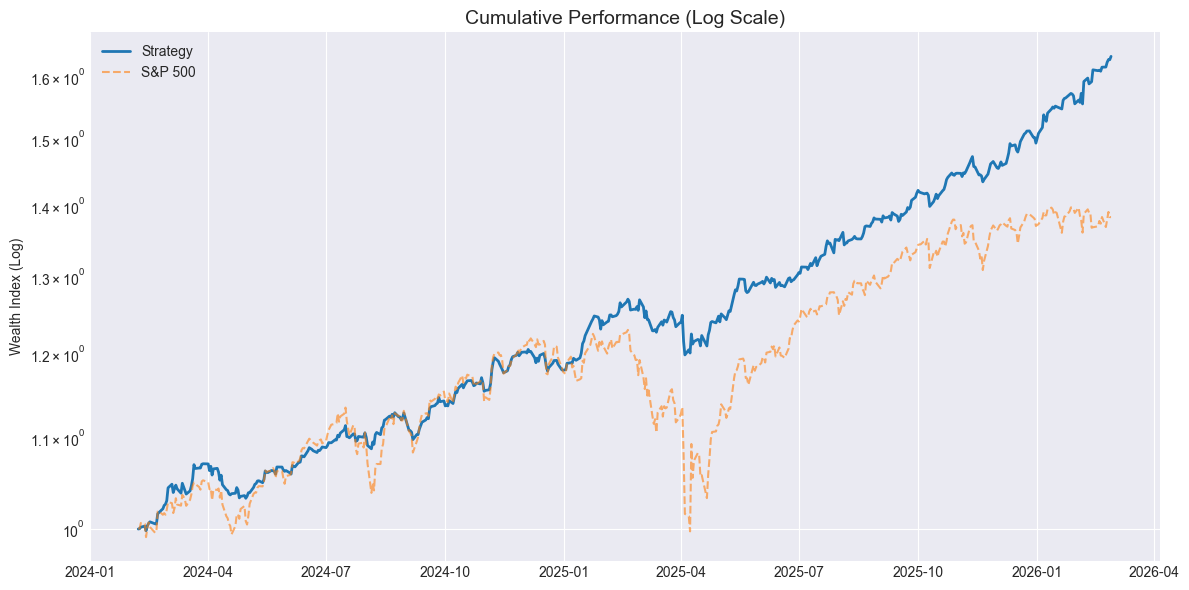

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Strategy Cumulative
strat_cum = (1 + returns).cumprod()
ax.plot(strat_cum.index, strat_cum, label='Strategy', linewidth=2)

# Benchmark Cumulative
if spy_returns is not None:
    bench_cum = (1 + spy_returns).cumprod()
    # Rebase benchmark to strategy start
    bench_cum = bench_cum * strat_cum.iloc[0] / bench_cum.iloc[0]
    ax.plot(bench_cum.index, bench_cum, label='S&P 500', alpha=0.6, linestyle='--')

ax.set_title('Cumulative Performance (Log Scale)', fontsize=14)
# Log scale linearizes compounding: straight line = constant CAGR.
# Helps visualize relative performance consistency over time.
ax.set_yscale('log')
ax.legend()
ax.set_ylabel('Wealth Index (Log)')
plt.tight_layout()
plt.show()

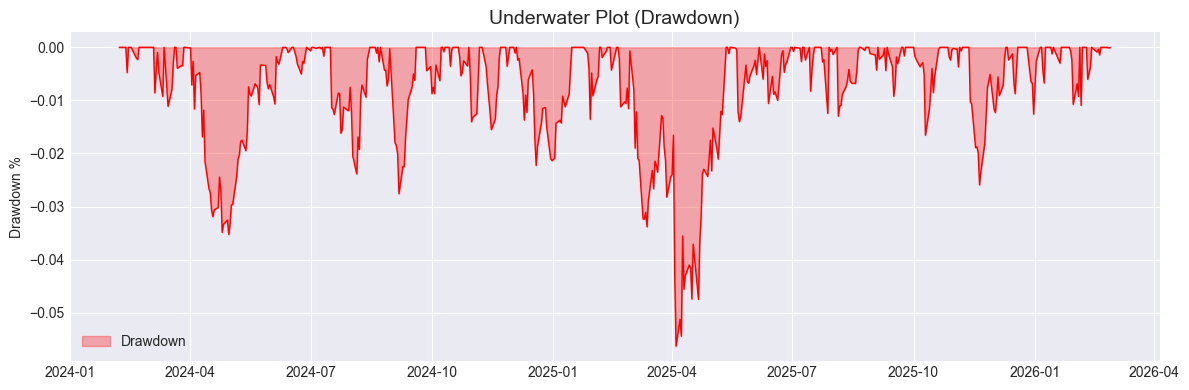

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

cum = (1 + returns).cumprod()
peak = cum.cummax()
dd = (cum - peak) / peak

ax.fill_between(dd.index, dd, 0, color='red', alpha=0.3, label='Drawdown')
ax.plot(dd.index, dd, color='red', linewidth=1)
ax.set_title('Underwater Plot (Drawdown)', fontsize=14)
ax.set_ylabel('Drawdown %')
ax.legend()
plt.tight_layout()
plt.show()

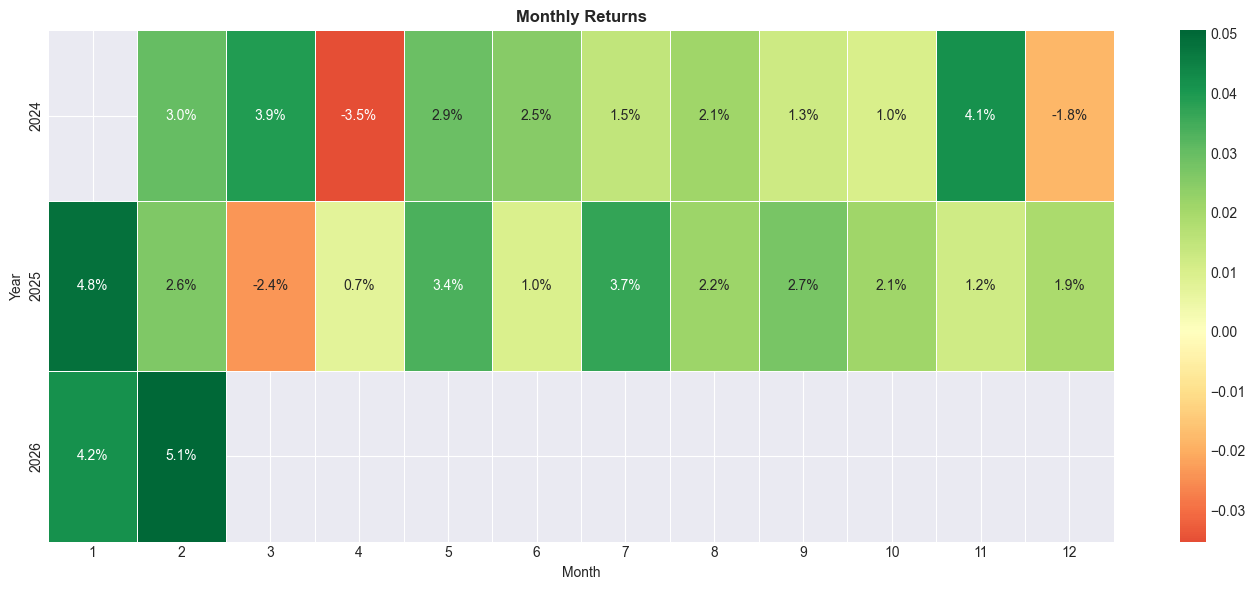

In [6]:
try:
    plot_monthly_heatmap(returns)
    plt.show()
except Exception as e:
    print(f"Heatmap error: {e}")

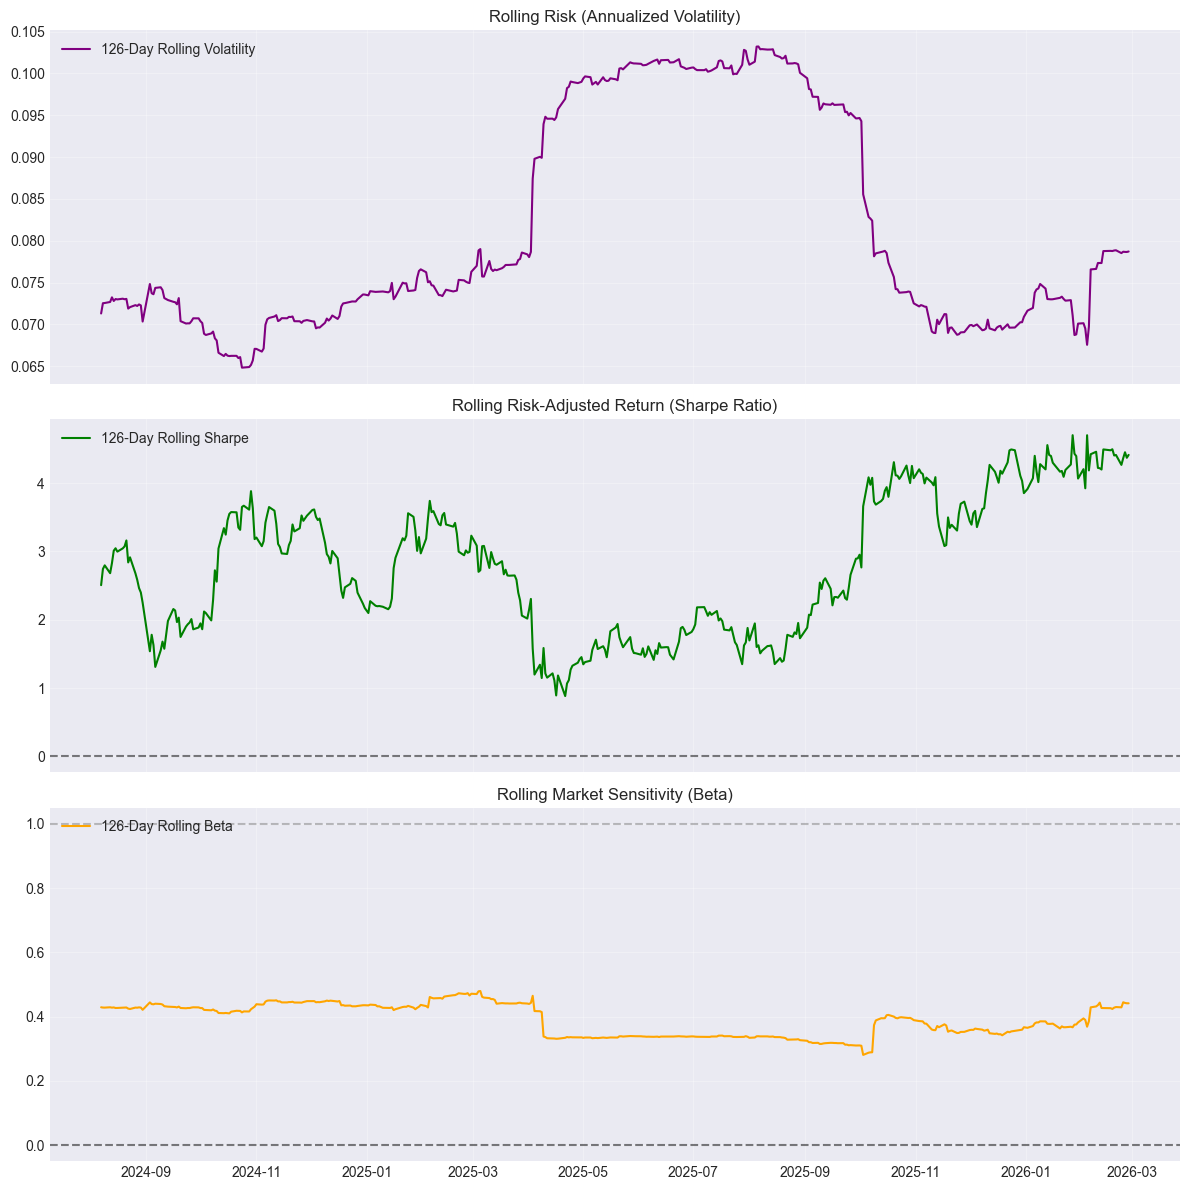

In [7]:
# --- Rolling Statistics (Institutional) ---
# 126 days = 6 months (252 trading days / 2). 
# Standard institutional lookback for regime stability analysis.
window = 126

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1. Rolling Volatility
rolling_vol = returns.rolling(window).std() * np.sqrt(252)
axes[0].plot(rolling_vol, color='purple', label=f'{window}-Day Rolling Volatility')
axes[0].set_title('Rolling Risk (Annualized Volatility)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Rolling Sharpe
rolling_mean = returns.rolling(window).mean() * 252
rolling_sharpe = rolling_mean / (rolling_vol + 1e-6)
axes[1].plot(rolling_sharpe, color='green', label=f'{window}-Day Rolling Sharpe')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Rolling Risk-Adjusted Return (Sharpe Ratio)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# 3. Rolling Beta (if benchmark available)
if spy_returns is not None:
    # Align data for rolling calc
    df_roll = pd.concat([returns, spy_returns], axis=1).dropna()
    df_roll.columns = ['strat', 'bench']
    
    cov = df_roll['strat'].rolling(window).cov(df_roll['bench'])
    var = df_roll['bench'].rolling(window).var()
    rolling_beta = cov / (var + 1e-6)
    
    axes[2].plot(rolling_beta, color='orange', label=f'{window}-Day Rolling Beta')
    axes[2].axhline(1, color='gray', linestyle='--', alpha=0.5)
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_title('Rolling Market Sensitivity (Beta)')
    axes[2].legend(loc='upper left')
else:
    axes[2].text(0.5, 0.5, "Benchmark data not available for Beta", ha='center')
    axes[2].set_title('Rolling Beta (Missing Benchmark)')

axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

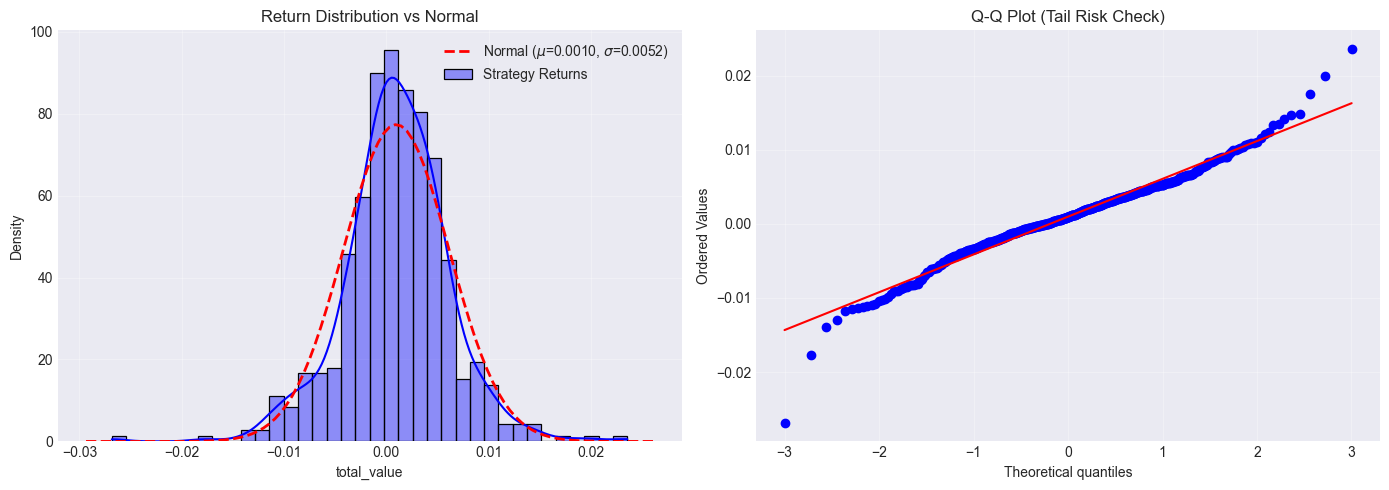

Skewness: -0.20 (Negative = frequent small gains, rare large losses)
Kurtosis: 2.77 (High = fat tails / extreme events)


In [8]:
# --- Return Distribution Analysis (Tail Risk) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram & KDE
sns.histplot(returns, kde=True, stat="density", ax=axes[0], color='blue', alpha=0.4, label='Strategy Returns')
# Overlay Normal Distribution
mu, std = returns.mean(), returns.std()
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'r--', linewidth=2, label=f'Normal ($\mu$={mu:.4f}, $\sigma$={std:.4f})')
axes[0].set_title("Return Distribution vs Normal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Q-Q Plot
stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].get_lines()[1].set_color('red') # Regression line color
axes[1].set_title("Q-Q Plot (Tail Risk Check)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Higher Moments Interpretation
print(f"Skewness: {returns.skew():.2f} (Negative = frequent small gains, rare large losses)")
print(f"Kurtosis: {returns.kurtosis():.2f} (High = fat tails / extreme events)")

## 4. Conclusions & Artifacts
Save the performance metrics for downstream reporting.

In [9]:
metrics_path = config.RESULTS_DIR / 'backtest_mean_variance' / 'performance_metrics.csv'
stats_df.to_frame("Strategy Metrics").to_csv(metrics_path)
print(f"Performance metrics saved to: {metrics_path}")

Performance metrics saved to: E:\coding\quant_alpha_research\results\backtest_mean_variance\performance_metrics.csv
